## Email Spam Classifier

In [230]:
import numpy as np
import pandas as pd

In [42]:
df = pd.read_csv('spam.csv' , encoding = 'latin-1')

In [43]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4592,ham,It's ok i wun b angry. Msg u aft i come home t...,NaN,NaN,NaN
2820,ham,Oh god..taken the teeth?is it paining,NaN,NaN,NaN
614,ham,I called and said all to him:)then he have to ...,NaN,NaN,NaN
922,ham,It shall be fine. I have avalarr now. Will hol...,NaN,NaN,NaN
3790,spam,"Twinks, bears, scallies, skins and jocks are c...",NaN,NaN,NaN


In [44]:
df.shape

(5572, 5)

## 1. Data Cleaning

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [46]:
# Dropping the last three Columns
df.drop(columns = ['Unnamed: 2','Unnamed: 3','Unnamed: 4'] , inplace = True)

In [47]:
df.sample(5)

,v1,v2
2321,ham,Ok...
1940,ham,Dude avatar 3d was imp. At one point i thought...
3427,ham,\Hi darlin did youPhone me? Im atHome if youwa...
4871,ham,Hi dis is yijue i would be happy to work wif Ì...
2698,spam,FROM 88066 LOST å£12 HELP


In [48]:
# Renaming the Columns
df.rename(columns = {'v1':'Target' , 'v2':'Text'} , inplace = True)

In [49]:
df.sample(5)

,Target,Text
5503,ham,Perhaps * is much easy give your account ident...
4330,ham,Nope i'll come online now..
654,ham,Did u got that persons story
5085,ham,Sorry i missed your call. Can you please call ...
5406,ham,Dear are you angry i was busy dear


In [50]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [51]:
df['Target'] = encoder.fit_transform(df['Target']) 

In [52]:
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [53]:
# Check for Null Values
df.isnull().sum()

Target    0
Text      0
dtype: int64

In [54]:
# Check for Duplicate Values
df.duplicated().sum()

np.int64(403)

In [55]:
# Remove the Duplicates
df = df.drop_duplicates(keep='first')

In [56]:
df.duplicated().sum()

np.int64(0)

In [57]:
df.shape

(5169, 2)

## 2. Exploratory Data Analysis (EDA)

In [58]:
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [59]:
df['Target'].value_counts()

Target
0    4516
1     653
Name: count, dtype: int64

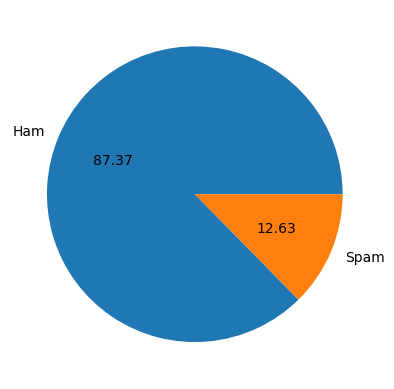

In [60]:
import matplotlib.pyplot as plt
plt.pie(df['Target'].value_counts() , labels =['Ham','Spam'] , autopct = '%0.2f')
plt.show()

In [61]:
# Data is Imbalanced

In [62]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to C:\Users\Rayyan
[nltk_data]     Tech\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [63]:
!pip install nltk

In [64]:
# Fetch Number of Characters
df['Num_Characters'] = df['Text'].apply(len)

In [65]:
df.head()

,Target,Text,Num_Characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [66]:
# Fetching Number of Words
df['Num_Words'] = df['Text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [67]:
df.head()

,Target,Text,Num_Characters,Num_Words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [68]:
# Fetching Number of Sentences
df['Num_Sentences'] = df['Text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [69]:
df.head()

,Target,Text,Num_Characters,Num_Words,Num_Sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [70]:
# Getting info on all Messages
df[['Num_Characters' , 'Num_Words' , 'Num_Sentences']].describe()

,Num_Characters,Num_Words,Num_Sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [71]:
# Getting info on Ham Messages
df[df['Target'] == 0][['Num_Characters' , 'Num_Words' , 'Num_Sentences']].describe()

,Num_Characters,Num_Words,Num_Sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [72]:
# Getting info on Spam Messages
df[df['Target'] == 1][['Num_Characters' , 'Num_Words' , 'Num_Sentences']].describe()

,Num_Characters,Num_Words,Num_Sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [73]:
# Data Visualization
import seaborn as sns

<Axes: xlabel='Num_Characters', ylabel='Count'>

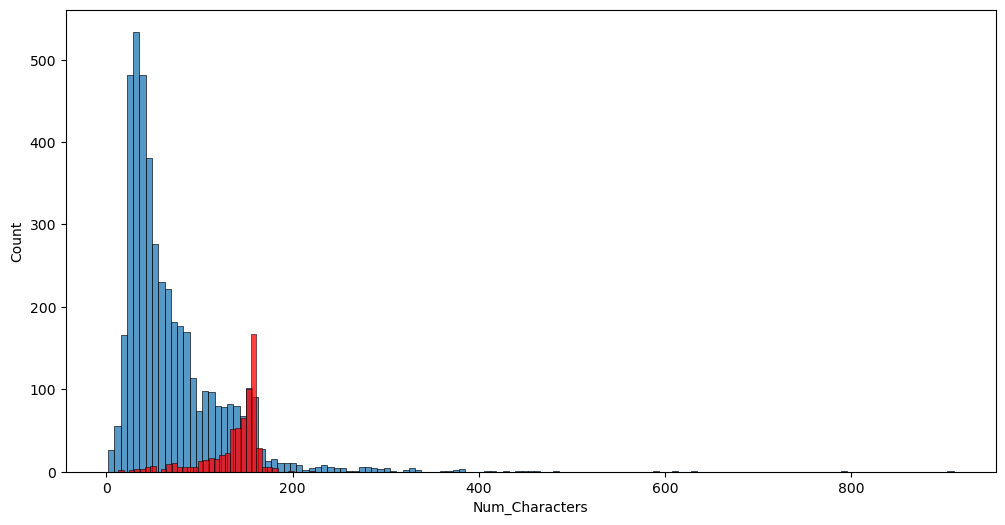

In [74]:
plt.figure(figsize = (12,6))
sns.histplot(df[df['Target'] == 0]['Num_Characters'])
sns.histplot(df[df['Target'] == 1]['Num_Characters'] , color = 'red')

<Axes: xlabel='Num_Words', ylabel='Count'>

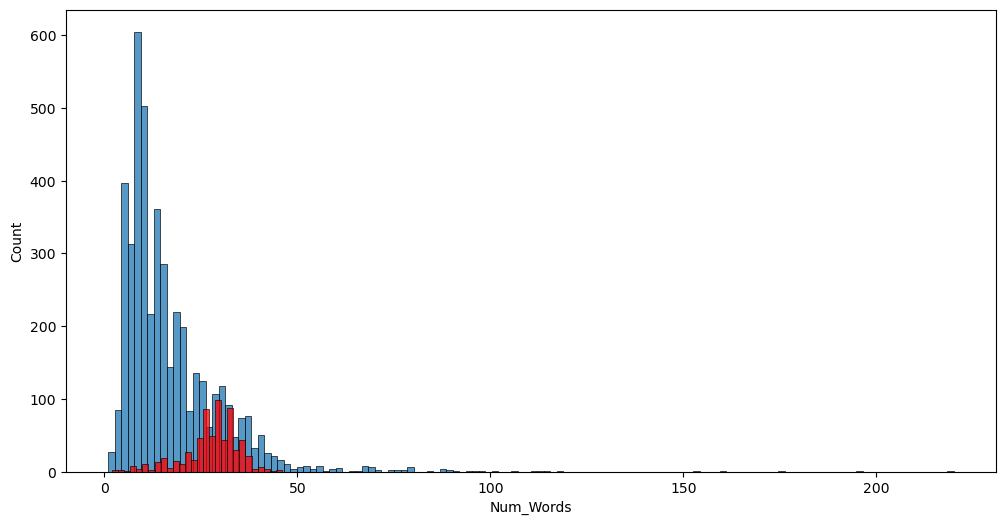

In [75]:
plt.figure(figsize = (12,6))
sns.histplot(df[df['Target'] == 0]['Num_Words'])
sns.histplot(df[df['Target'] == 1]['Num_Words'] , color = 'red')

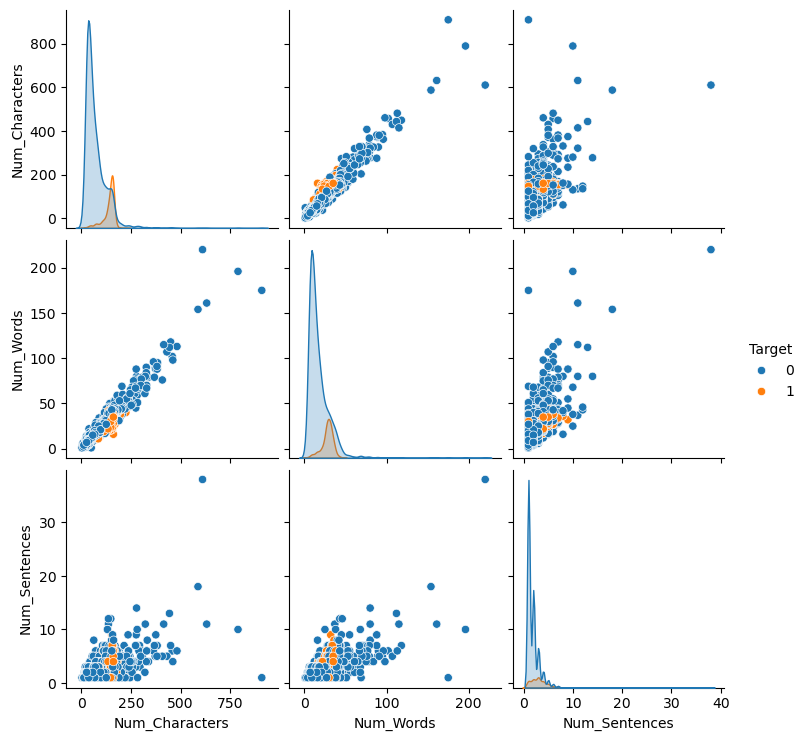

In [76]:
sns.pairplot(df,hue='Target')

<Axes: >

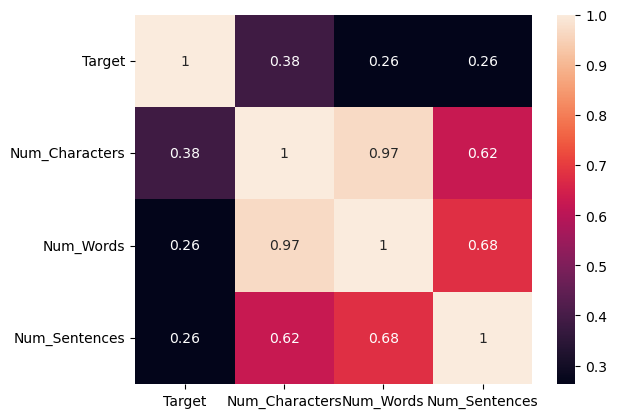

In [77]:
sns.heatmap(df.corr(numeric_only = True) , annot = True)

## 3. Data Preprocessing

In [90]:
def transform_text(text):
    # For lowercase
    text = text.lower()

    # For Tokenizing each word
    text = nltk.word_tokenize(text)

    # For removing special characters
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    # For removing stop words and punctuation
    text = y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i) 

    # For Stemming
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))

    
    return " ".join(y)

In [91]:
import string
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to C:\Users\Rayyan
[nltk_data]     Tech\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [92]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [93]:
df['Transform_Text'] = df['Text'].apply(transform_text)

In [94]:
df.head()

,Target,Text,Num_Characters,Num_Words,Num_Sentences,Transform_Text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [95]:
# Creating Word Cloud
!pip install wordcloud

In [96]:
from wordcloud import WordCloud
wc = WordCloud(width=400,height=400,min_font_size=10,background_color='white')

In [97]:
# For Spam Messages
spam_wc = wc.generate(df[df['Target'] == 1]['Transform_Text'].str.cat(sep=" "))

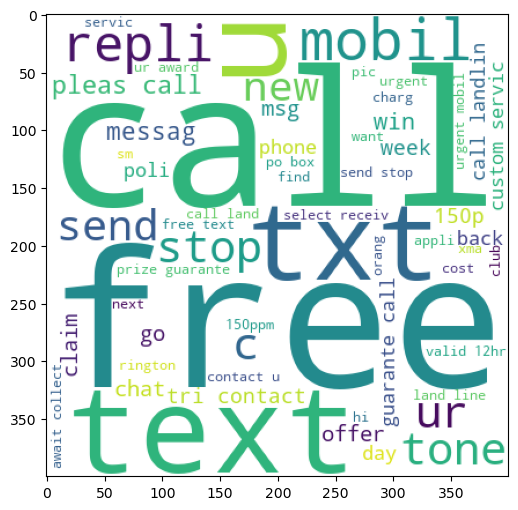

In [98]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [99]:
# For Ham Messages
ham_wc = wc.generate(df[df['Target'] == 0]['Transform_Text'].str.cat(sep=" "))

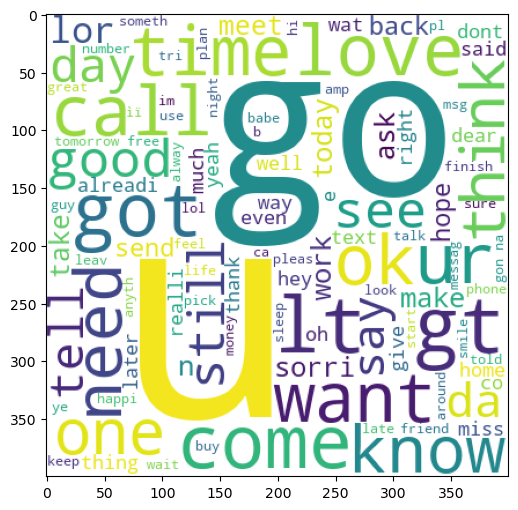

In [100]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [101]:
df.head()

,Target,Text,Num_Characters,Num_Words,Num_Sentences,Transform_Text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [102]:
# Finding out the most used word in Spam
spam_corpus = []
for msg in df[df['Target'] == 1]['Transform_Text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [103]:
# Number of Words
len(spam_corpus)

9939

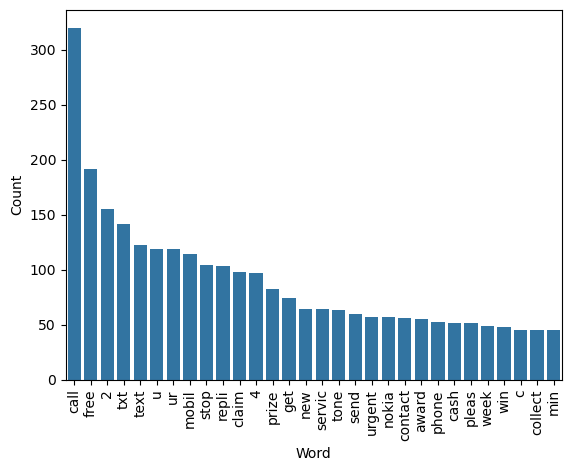

In [104]:
from collections import Counter
most_common_df = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['Word', 'Count'])
sns.barplot(data=most_common_df, x='Word', y='Count')
plt.xticks(rotation='vertical')
plt.show()

In [105]:
# Finding out the most used word in Ham
ham_corpus = []
for msg in df[df['Target'] == 0]['Transform_Text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [106]:
# Number of Words
len(ham_corpus)

35404

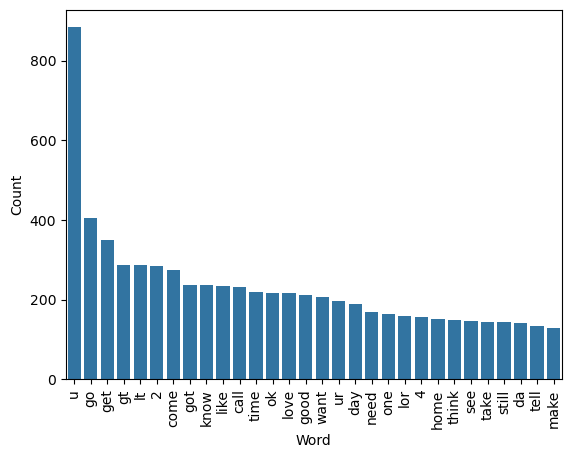

In [107]:
most_common_df = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['Word', 'Count'])
sns.barplot(data=most_common_df, x='Word', y='Count')
plt.xticks(rotation='vertical')
plt.show()

## 4. Model Building

In [215]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [216]:
X = tfidf.fit_transform(df['Transform_Text']).toarray()

In [217]:
X.shape

(5169, 3000)

In [218]:
y = df['Target'].values

In [219]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [220]:
from sklearn.model_selection import train_test_split

In [221]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [222]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [223]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [224]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))


0.8694390715667312
[[788 108]
 [ 27 111]]
0.5068493150684932


In [225]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [226]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [227]:
# We have chosen tfidf --> Multinomial Naive Bayes (as Precision is 1 and Accuracy is 97)
# We will not be using Scaler because it brings down Precision Score

In [229]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))